<a href="https://colab.research.google.com/github/PrinceofJ/ONESTRUCTION-Point-Cloud-to-BIM/blob/sam-only/June24RoomSegmentation_PipelineA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🛠️ Step 1: Environment Setup, Dependencies & Imports
**What this does:** This cell initializes the entire Colab environment in one go. It performs the following actions:
1. **Verifies GPU Access:** Checks that a T4 GPU is assigned.
2. **Installs Dependencies:** Downloads and installs `open3d`, `segment-anything`, `opencv-python`, `supervision`, and `jupyter_bbox_widget`.
3. **Downloads Weights:** Fetches the Meta SAM `vit_h` model checkpoint.
4. **Mounts Google Drive:** Connects your Drive so you can load datasets and save outputs.
5. **Loads Imports:** Imports all necessary Python libraries used throughout the pipeline to keep the rest of the notebook clean.
6. **Cleans Directory:** Removes any lingering `.ply` files from previous runs to prevent conflicts.

*(Note: If Colab prompts you to restart the session after installing Open3D, do so, and then run this cell one more time!)*

In [1]:
# 1. GPU Check
!nvidia-smi

# 2. Install Dependencies
!pip install -q open3d segment-anything opencv-python supervision jupyter_bbox_widget

# 3. Download SAM Weights (The -nc flag prevents re-downloading if it already exists)
!wget -q -nc https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

# 4. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 5. Clean Workspace
!rm -f /content/*.ply
print("Workspace cleaned.")

# 6. Global Imports (Do not add imports anywhere else in the notebook!)
import os
import gc
import cv2
import torch
import torchvision
import numpy as np
import pandas as pd
import open3d as o3d
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import zipfile
from google.colab import files

print("\n--- ENVIRONMENT SETUP COMPLETE ---")
print("PyTorch version:", torch.__version__)
print("CUDA is available:", torch.cuda.is_available())

Wed Jun 24 02:09:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P0             30W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 🚀 Phase 1: Universal Data Loader, Thick Z-Slicing & CCA Noise Removal

**What this does:**
We have upgraded from the legacy RANSAC ceiling detection (which often fails on complex ceilings) to a robust, memory-safe ingestion layer tailored for sparse LiDAR.
1. **Universal Chunked Loader:** Safely reads massive `.txt`, `.xyz`, or `.ply` point clouds in 1-million-row chunks to prevent Colab RAM exhaustion.
2. **Thick Z-Slicing:** References the true floor mathematically and takes a dense 1.5-meter vertical slice (from 1.0m to 2.5m). This squashes vertical data down to naturally heal sparse wall segments and broken lines.
3. **CCA Noise Removal:** Applies Connected Component Analysis to the 2D footprint, mathematically erasing isolated clutter and humans (pixel islands < 1000 pixels) while leaving structural walls completely intact.

**Instructions:**
Change the `FILE_PATH` variable in the code below to point to your specific point cloud file (e.g., `/content/drive/MyDrive/ONESTRUCTION/...`).

--- PHASE 1: UNIVERSAL LOADER & THICK SLICING ---
Detected file format: .txt
Initiating Memory-Safe Chunked Text Loader...
Point count (32,597,694) exceeds limits. Downsampling at 0.02m...
Successfully loaded 5,012,670 points.
Captured 2,705,972 points for the thick wall slice.

--- PHASE 2: CCA NOISE REMOVAL ---
CCA Filter Complete: Mathematically removed 695 noise islands.


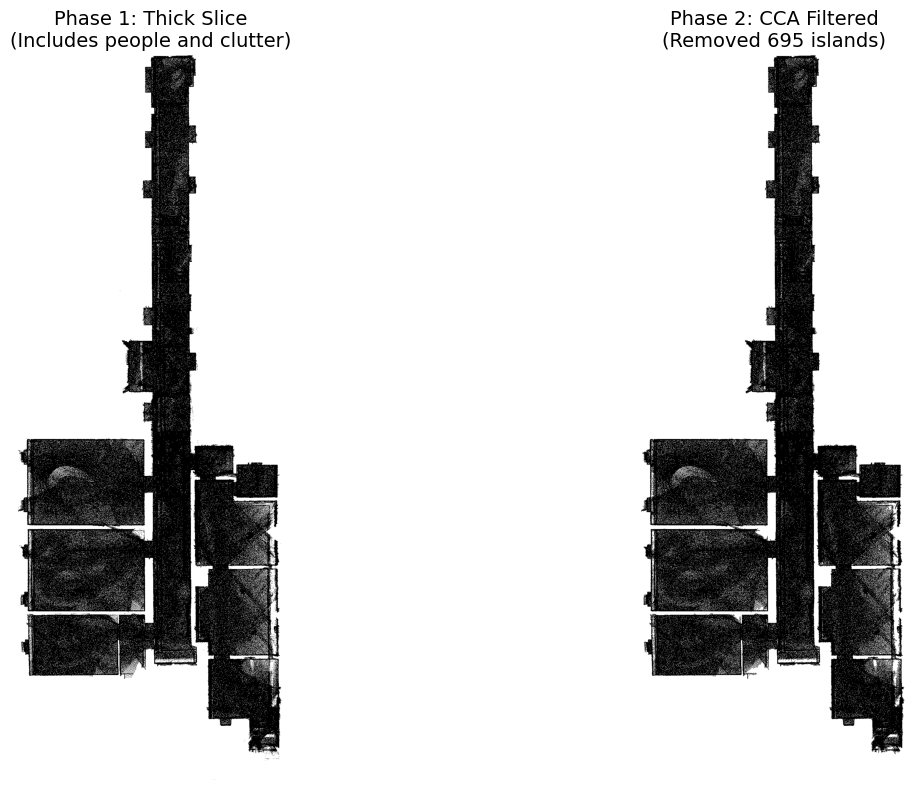

Ms_grid (slice -> SAM):      (2141, 783)  occupied px = 575,333
Mf_grid (full -> retrieval): (2141, 783)  occupied px = 636,979


In [2]:
print("--- PHASE 1: UNIVERSAL LOADER & THICK SLICING ---")

# --- GLOBAL PARAMETERS ---
FILE_PATH = '/content/drive/MyDrive/ONESTRUCTION/Uni_PointCloud_cs1.txt'  # Works with .txt, .ply, .xyz
PIXEL_SIZE = 0.02
MAX_SAFE_POINTS = 15_000_000             # Prevents Colab RAM crashes

# 1. ROBUST UNIVERSAL LOADER
def load_point_cloud_safely(path, max_points, voxel_size):
    ext = os.path.splitext(path)[1].lower()
    print(f"Detected file format: {ext}")

    if ext in ['.ply', '.pcd', '.xyz']:
        # Open3D handles binary and standard .xyz files very efficiently
        pcd = o3d.io.read_point_cloud(path)

    elif ext == '.txt':
        print("Initiating Memory-Safe Chunked Text Loader...")
        all_points = []

        # CHUNKING: Read 1 million rows at a time to prevent RAM crashes
        chunk_iterator = pd.read_csv(path, sep=r'\s+|,', header=None, engine='python', chunksize=1_000_000)

        for i, chunk in enumerate(chunk_iterator):
            # Extract only Geometry (XYZ) to save memory for rasterization
            all_points.append(chunk.iloc[:, 0:3].values)
            del chunk # Imperative: Free up memory immediately

        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(np.vstack(all_points))
        del all_points; gc.collect()

    else:
        raise ValueError(f"Unsupported format: {ext}")

    # Memory Guard: Voxel Downsampling if too large
    if len(pcd.points) > max_points:
        print(f"Point count ({len(pcd.points):,}) exceeds limits. Downsampling at {voxel_size}m...")
        pcd = pcd.voxel_down_sample(voxel_size=voxel_size)

    print(f"Successfully loaded {len(pcd.points):,} points.")
    return pcd

pcd = load_point_cloud_safely(FILE_PATH, MAX_SAFE_POINTS, PIXEL_SIZE)
points = np.asarray(pcd.points)

# 2. THE THICK SLICE (1.0m to 2.5m)
z_coords = points[:, 2]
z_floor = np.percentile(z_coords, 1.0)
SLICE_MIN = z_floor + 1.0
SLICE_MAX = z_floor + 2.5

wall_slice_points = points[(z_coords >= SLICE_MIN) & (z_coords <= SLICE_MAX)]
print(f"Captured {len(wall_slice_points):,} points for the thick wall slice.")

# 3. 2D RASTERIZATION
min_x, min_y = np.min(points[:, 0]), np.min(points[:, 1])
x_idx = ((wall_slice_points[:, 0] - min_x) / PIXEL_SIZE).astype(int)
y_idx = ((wall_slice_points[:, 1] - min_y) / PIXEL_SIZE).astype(int)

width = int((np.max(points[:, 0]) - min_x) / PIXEL_SIZE) + 1
height = int((np.max(points[:, 1]) - min_y) / PIXEL_SIZE) + 1

Ms_raw = np.full((height, width), 255, dtype=np.uint8)
Ms_raw[height - 1 - y_idx, x_idx] = 0


print("\n--- PHASE 2: CCA NOISE REMOVAL ---")

# 1. Invert image (Walls = White, Empty Space = Black)
Ms_inverted = cv2.bitwise_not(Ms_raw)

# 2. CONNECTED COMPONENT ANALYSIS (CCA)
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(Ms_inverted, connectivity=8)
Ms_filtered = np.zeros_like(Ms_inverted)

# 3. THE AREA FILTER (Delete islands smaller than 1000 pixels)
MIN_AREA_PIXELS = 1000
removed_islands = 0

for i in range(1, num_labels): # Skip 0 (background)
    area = stats[i, cv2.CC_STAT_AREA]
    if area >= MIN_AREA_PIXELS:
        Ms_filtered[labels == i] = 255 # Keep wall
    else:
        removed_islands += 1 # Delete noise

# Revert to standard formatting (Black walls, White space)
Ms_final = cv2.bitwise_not(Ms_filtered)
cv2.imwrite('/content/Ms_cleaned_baseline.png', Ms_final)

print(f"CCA Filter Complete: Mathematically removed {removed_islands} noise islands.")

# --- DIAGNOSTIC ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(Ms_raw, cmap='gray')
axes[0].set_title("Phase 1: Thick Slice\n(Includes people and clutter)", fontsize=14)
axes[0].axis('off')

axes[1].imshow(Ms_final, cmap='gray')
axes[1].set_title(f"Phase 2: CCA Filtered\n(Removed {removed_islands} islands)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()


# ============================================================
# PAPER GRIDS: Ms (slice -> SAM)  and  Mf (full projection -> retrieval)
# Albadri et al. §3.1: Ms = thin-section occupancy for mask generation,
#                      Mf = FULL point cloud projected to x-y for point retrieval.
# Both share the SAME grid (width/height/min_x/min_y/PIXEL_SIZE) so masks from
# Ms map 1:1 onto Mf. Convention: 0 = occupied (black), 255 = free (white).
# ============================================================

# Ms_grid = the cleaned slice occupancy that is sent to SAM (use CCA-filtered Ms_final)
Ms_grid = Ms_final.copy()

# Mf_grid = FULL cloud projected to the floor plane, SAME grid as Ms
mf_x_idx = ((points[:, 0] - min_x) / PIXEL_SIZE).astype(int)
mf_y_idx = ((points[:, 1] - min_y) / PIXEL_SIZE).astype(int)
# clip to grid bounds (full cloud can exceed the slice extents by a pixel)
mf_in = (mf_x_idx >= 0) & (mf_x_idx < width) & (mf_y_idx >= 0) & (mf_y_idx < height)
Mf_grid = np.full((height, width), 255, dtype=np.uint8)
Mf_grid[height - 1 - mf_y_idx[mf_in], mf_x_idx[mf_in]] = 0     # occupied = 0

print(f"Ms_grid (slice -> SAM):      {Ms_grid.shape}  occupied px = {int((Ms_grid==0).sum()):,}")
print(f"Mf_grid (full -> retrieval): {Mf_grid.shape}  occupied px = {int((Mf_grid==0).sum()):,}")


### 🔍 Visualization 1: Thick Z-Slice Verification
**What this does:** This interactive 3D viewer allows us to verify that our floor-referenced Z-axis slicing correctly captured the dense structural walls without relying on unstable ceiling planes.
* **Grey Points:** The raw building data (discarded floor, ceiling, and clutter).
* **Blue Points:** The dense 1.5-meter "Thick Slice" (1.0m to 2.5m above the floor) that will be flattened into our 2D occupancy grid.

*(Note: The point cloud is heavily downsampled here solely to prevent the browser from crashing. The actual pipeline still uses the full-resolution data).*

In [3]:
print("--- 🔍 VISUALIZATION 1: THICK SLICE VERIFICATION ---")

# 1. Downsample for Browser Stability
# We limit the visual to ~50,000 points so Colab doesn't crash your browser tab
MAX_VIS_POINTS = 50000
step = max(1, len(points) // MAX_VIS_POINTS)
vis_points = points[::step]

# 2. Re-apply the Thick Slice logic just for the visualizer
z_coords_vis = vis_points[:, 2]
z_floor_vis = np.percentile(points[:, 2], 1.0) # Ground truth floor from full dataset
SLICE_MIN = z_floor_vis + 1.0
SLICE_MAX = z_floor_vis + 2.5

slice_mask = (z_coords_vis >= SLICE_MIN) & (z_coords_vis <= SLICE_MAX)

slice_pts = vis_points[slice_mask]
bg_pts = vis_points[~slice_mask]

# 3. Build the Interactive Plotly Figure
fig = go.Figure()

# Add Grey Background (The rest of the building)
fig.add_trace(go.Scatter3d(
    x=bg_pts[:, 0], y=bg_pts[:, 1], z=bg_pts[:, 2],
    mode='markers',
    marker=dict(size=1.5, color='lightgrey', opacity=0.2),
    name='Raw Building (Discarded)'
))

# Add Blue Slice (The core walls we are keeping)
fig.add_trace(go.Scatter3d(
    x=slice_pts[:, 0], y=slice_pts[:, 1], z=slice_pts[:, 2],
    mode='markers',
    marker=dict(size=2.0, color='blue', opacity=0.9),
    name='Thick Wall Slice (1.0m - 2.5m)'
))

fig.update_layout(
    title="Interactive 3D Viewer: Floor-Referenced Thick Slice",
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        aspectmode='data' # Keeps real-world proportions!
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

print("Rendering interactive viewer...")
fig.show()

--- 🔍 VISUALIZATION 1: THICK SLICE VERIFICATION ---
Rendering interactive viewer...


### 🗺️ Visualization 1.5: 2D Occupancy & Mathematical Noise Removal
**What this does:** This displays the 2D rasterized footprint of our thick slice before and after our Connected Component Analysis (CCA) filter. This proves the necessity of pre-filtering LiDAR data before passing it to foundation models.
* **Image 1 (Raw Thick Slice):** Contains severe LiDAR noise, including people in corridors and furniture. If fed directly to SAM, these artifacts would cause hallucinated boundaries.
* **Image 2 (CCA Filtered):** The pristine structural footprint. By mathematically erasing isolated pixel islands (under 1000 pixels), we remove the clutter while perfectly preserving the continuous walls. *This is the final image sent to SAM.*

--- 🗺️ VISUALIZATION 1.5: CCA NOISE REMOVAL ---


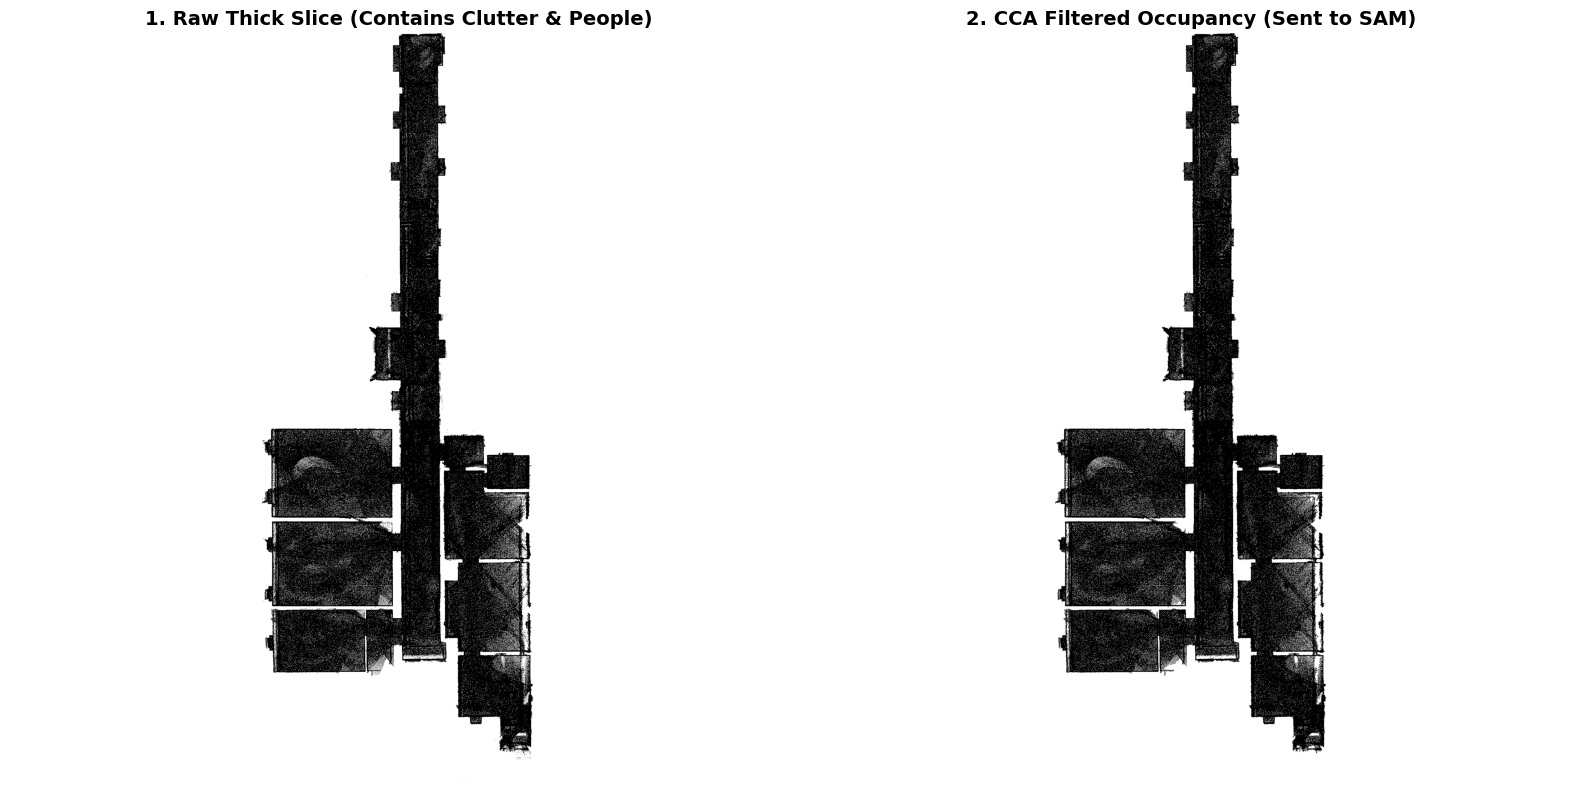

In [9]:
print("--- 🗺️ VISUALIZATION 1.5: CCA NOISE REMOVAL ---")

# We use the Ms_raw and Ms_final variables still sitting in Colab's memory from Phase 1
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot the Raw Slice (Before Filter)
axes[0].imshow(Ms_raw, cmap='gray')
axes[0].set_title("1. Raw Thick Slice (Contains Clutter & People)", fontsize=14, fontweight='bold')
axes[0].axis('equal')
axes[0].axis('off') # Hide pixel axes for cleaner look

# Plot the Cleaned Slice (After Filter)
# Note: If your Phase 1 named the final variable 'Ms_grid' instead of 'Ms_final', change it here!
axes[1].imshow(Ms_final, cmap='gray')
axes[1].set_title("2. CCA Filtered Occupancy (Sent to SAM)", fontsize=14, fontweight='bold')
axes[1].axis('equal')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 🧠 Phase 2: Pipeline A Baseline (SAM + Geometric Post-Filtering)
**What this does:** This script executes the core methodology of our paper's baseline model. Rather than relying on SAM for perfect zero-shot segmentation, we use SAM as a "permissive candidate generator" and mathematically classify its outputs.

1. **Candidate Generation:** We run SAM with a relaxed stability threshold (`0.93`) on our thick-slice footprint to aggressively over-generate structural boundaries.
2. **Mathematical Classification:** We pass all raw masks through a strict 4-part geometric filter to eliminate hallucinations:
   * **Area Rule:** Rejects spaces < 1.5 m² or > 200 m².
   * **Footprint Rule:** Rejects exterior environment slabs touching the image boundary.
   * **Topology Rule:** Rejects nested container masks (IoU > 85%).
   * **Shape Rule:** Rejects hallucinated LiDAR slivers using a compactness ratio (Perimeter² / Area > 75).
3. **High-Fidelity 3D Retrieval:** The surviving mathematically valid masks are dilated by 10cm and mapped directly back to the 3D point indices in memory, exporting the final rooms as standardized `.ply` files.

In [5]:
print("--- PIPELINE A: THE PAPER'S TRUE BASELINE (SAM + GEOMETRIC POST-FILTER) ---")

# --- PIPELINE SAFETY CHECK ---
try:
    _ = PIXEL_SIZE; _ = points; _ = min_x; _ = min_y; _ = mf_x_idx; _ = mf_y_idx; _ = mf_in; _ = Ms_grid; _ = height; _ = width
except NameError:
    raise RuntimeError("CRITICAL: Phase 1 variables not found. Run Phase 1 first.")

print("--- MEMORY FLUSH ---")
torch.cuda.empty_cache()
gc.collect()

# ====================================================================
# STEP 1: THE WIDE NET (SAM CANDIDATE GENERATION)
# ====================================================================
print("\n1. Initializing SAM (Permissive Baseline Parameters)...")
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
sam = sam_model_registry["vit_h"](checkpoint="/content/sam_vit_h_4b8939.pth").to(device=DEVICE)

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,          # Standard dense seeding
    pred_iou_thresh=0.85,
    stability_score_thresh=0.93, # Author's recommended middle-ground (0.92-0.95)
    min_mask_region_area=100
)

print("SAM is analyzing the thick-slice floor plan...")
Ms_rgb = cv2.cvtColor(Ms_grid, cv2.COLOR_GRAY2RGB)
raw_sam_masks = mask_generator.generate(Ms_rgb)
print(f"SAM generated {len(raw_sam_masks)} raw candidate masks.")

# ====================================================================
# STEP 2: MASK CLASSIFICATION (THE GEOMETRIC POST-FILTER)
# ====================================================================
print("\n2. Applying Geometric & Topological Post-Filters...")

MIN_ROOM_SQ_METERS = 1.5
MAX_ROOM_SQ_METERS = 200.0

min_pixels = int(MIN_ROOM_SQ_METERS / (PIXEL_SIZE ** 2))
max_pixels = int(MAX_ROOM_SQ_METERS / (PIXEL_SIZE ** 2))

def classify_and_filter_masks(masks, img_width, img_height):
    # Sort masks from smallest to largest to easily detect nested containers
    sorted_masks = sorted(masks, key=lambda x: x['area'])
    valid_masks = []

    rejections = {"area": 0, "exterior": 0, "container": 0, "sliver": 0}

    for candidate in sorted_masks:
        seg_mask = candidate['segmentation']
        area_pixels = candidate['area']

        # A. AREA CHECK
        if not (min_pixels < area_pixels < max_pixels):
            rejections["area"] += 1
            continue

        # B. FOOTPRINT MEMBERSHIP CHECK (Kill Exterior Slabs)
        # Exterior slabs inevitably touch the outer boundary of the padded 2D image.
        # If any True pixel in the mask lies on the image edge, it is outside the building.
        touches_left = np.any(seg_mask[:, 0])
        touches_right = np.any(seg_mask[:, img_width-1])
        touches_top = np.any(seg_mask[0, :])
        touches_bottom = np.any(seg_mask[img_height-1, :])

        if touches_left or touches_right or touches_top or touches_bottom:
            rejections["exterior"] += 1
            continue

        # C. TOPOLOGY CHECK (Kill Nested Containers)
        # If a mask covers >85% of an already accepted smaller mask, it's a container.
        is_container = False
        for valid in valid_masks:
            intersection = np.logical_and(seg_mask, valid['segmentation'])
            if np.sum(intersection) / np.sum(valid['segmentation']) > 0.85:
                is_container = True
                break
        if is_container:
            rejections["container"] += 1
            continue

        # D. SHAPE CHECK (Kill Hallucinated Slivers)
        # Compactness = (Perimeter^2) / Area. A square is 16. A sliver is > 75.
        contours, _ = cv2.findContours(seg_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(contours) > 0:
            perimeter = cv2.arcLength(contours[0], True)
            compactness = (perimeter ** 2) / area_pixels if area_pixels > 0 else 999
            if compactness > 75:
                rejections["sliver"] += 1
                continue

        # If it passes all rules, it is a mathematically valid room!
        valid_masks.append(candidate)

    print(f"Filter Results:")
    print(f" - Rejected {rejections['area']} by Area (too small/large)")
    print(f" - Rejected {rejections['exterior']} by Footprint (exterior slabs)")
    print(f" - Rejected {rejections['container']} by Topology (nested containers)")
    print(f" - Rejected {rejections['sliver']} by Shape (hallucinated slivers)")

    return valid_masks

clean_masks = classify_and_filter_masks(raw_sam_masks, width, height)
print(f"\nMathematical Classification complete. {len(clean_masks)} valid rooms remain.")

# ====================================================================
# STEP 3: HIGH-FIDELITY 3D RETRIEVAL
# ====================================================================
print("\n3. Retrieving 3D Points...")
buffer_pixels = int(0.1 / PIXEL_SIZE) # 10cm outward buffer
valid_room_count = 0

points_in_grid = points[mf_in]
valid_x = mf_x_idx[mf_in]
valid_y = mf_y_idx[mf_in]

pcd_has_colors = hasattr(pcd, 'colors') and len(pcd.colors) > 0
if pcd_has_colors:
    colors_in_grid = np.asarray(pcd.colors)[mf_in]

# Create a diagnostic image for the paper
Mm_image = np.full((height, width, 3), 255, dtype=np.uint8)

for i, mask_data in enumerate(clean_masks):
    valid_room_count += 1
    mask_2d = mask_data['segmentation']

    # Paint diagnostic image
    color = np.random.randint(0, 200, 3).tolist()
    Mm_image[mask_2d] = color

    # Dilate mask to physically capture the LiDAR wall points
    buffered_mask = ndimage.binary_dilation(mask_2d, iterations=buffer_pixels)

    # Map 2D mask directly back to 3D point indices
    belongs_to_room = buffered_mask[height - 1 - valid_y, valid_x]
    room_3d_points = points_in_grid[belongs_to_room]

    if len(room_3d_points) > 100:
        room_pcd = o3d.geometry.PointCloud()
        room_pcd.points = o3d.utility.Vector3dVector(room_3d_points)

        # Preserve industrial-grade RGB extraction
        if pcd_has_colors:
            room_pcd.colors = o3d.utility.Vector3dVector(colors_in_grid[belongs_to_room])
        else:
            normalized_color = [c / 255.0 for c in color[::-1]] # BGR to RGB
            room_pcd.colors = o3d.utility.Vector3dVector(np.tile(normalized_color, (len(room_3d_points), 1)))

        output_path = f'/content/SAM_room_{valid_room_count}.ply'
        o3d.io.write_point_cloud(output_path, room_pcd, write_ascii=False)

# Save the 2D visual for the paper
cv2.imwrite('/content/Pipeline_A_Output.png', Mm_image)
print(f"Saved {valid_room_count} 3D rooms and 2D diagnostic visual (Pipeline_A_Output.png).")
print("---------------------------------")
print("Pipeline A Complete!")

--- PIPELINE A: THE PAPER'S TRUE BASELINE (SAM + GEOMETRIC POST-FILTER) ---
--- MEMORY FLUSH ---

1. Initializing SAM (Permissive Baseline Parameters)...
SAM is analyzing the thick-slice floor plan...
SAM generated 45 raw candidate masks.

2. Applying Geometric & Topological Post-Filters...
Filter Results:
 - Rejected 17 by Area (too small/large)
 - Rejected 6 by Footprint (exterior slabs)
 - Rejected 7 by Topology (nested containers)
 - Rejected 0 by Shape (hallucinated slivers)

Mathematical Classification complete. 15 valid rooms remain.

3. Retrieving 3D Points...
Saved 15 3D rooms and 2D diagnostic visual (Pipeline_A_Output.png).
---------------------------------
Pipeline A Complete!


### 🔬 Pipeline A Diagnostic: Geometric Post-Filter X-Ray
**Purpose:** This cell visualizes the "Candidate Generation -> Geometric Filtering" methodology. Because SAM is run with permissive thresholds (e.g., `stability_score=0.93`), it intentionally over-generates masks. This diagnostic tracks regressions and proves the efficacy of our topological rules.

**The 3-Panel Visual Tracks:**
1. **Raw SAM Candidates:** Every mask SAM hypothesized.
2. **The Rejection Graveyard:** Masks deleted by our algorithm, color-coded by the failing rule:
   * 🟨 **Yellow:** Failed Area Check (Too big/small)
   * 🟥 **Red:** Failed Footprint Check (Exterior slabs touching boundaries)
   * 🟦 **Blue:** Failed Topology Check (Nested container masks, IoU > 85%)
   * 🟪 **Purple:** Failed Shape Check (Hallucinated slivers, compactness > 75)
3. **Valid Rooms:** The surviving masks passed to 3D retrieval.

--- GENERATING PIPELINE A DIAGNOSTIC X-RAY ---


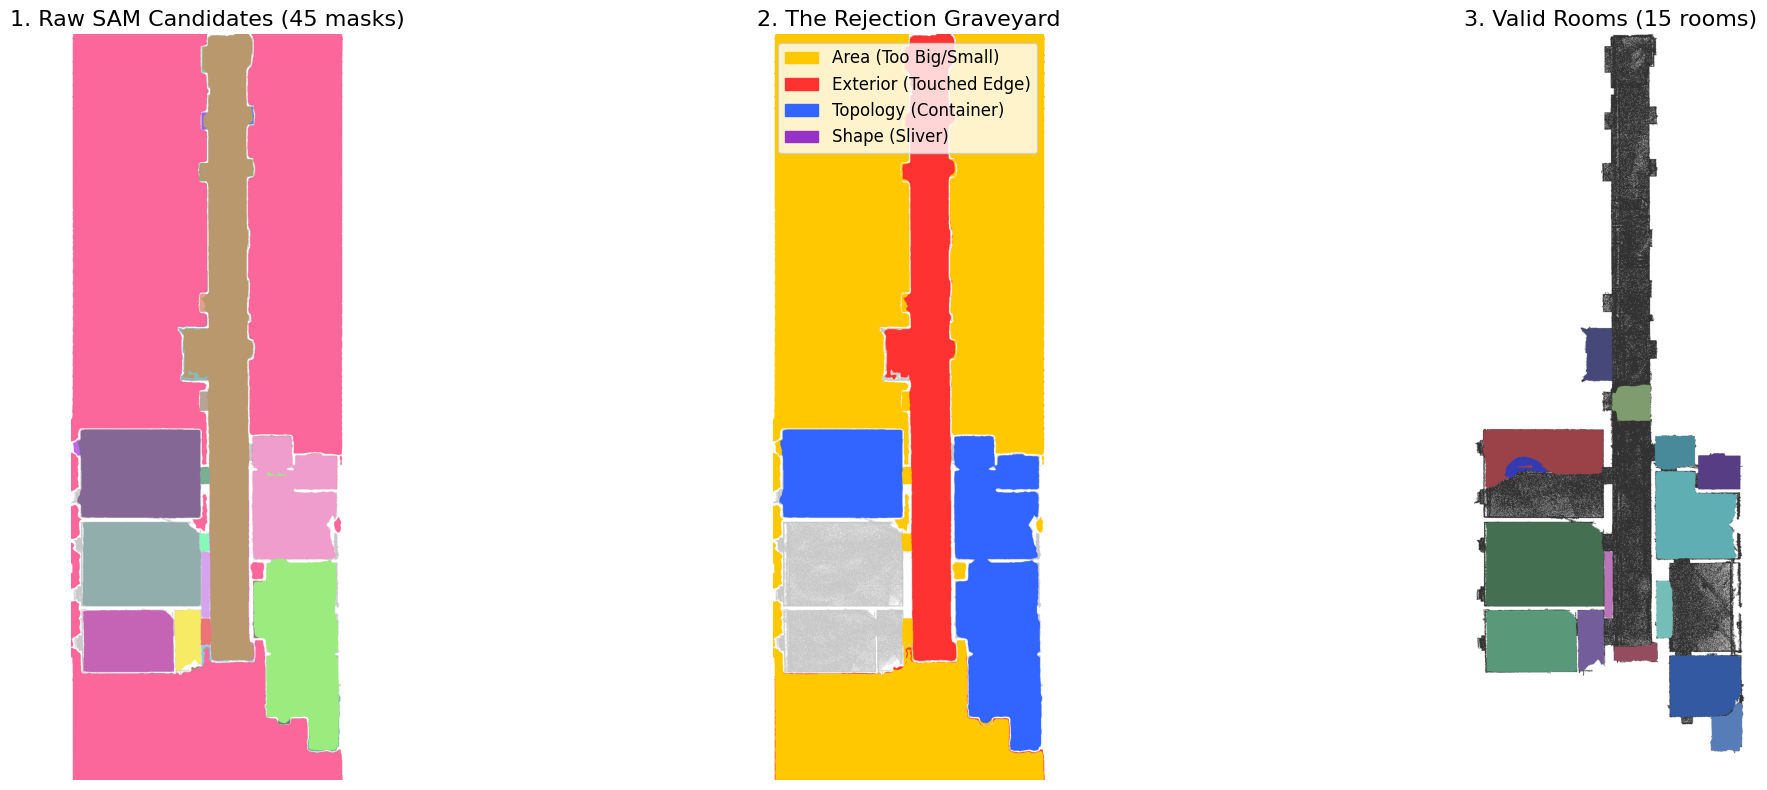

In [6]:
print("--- GENERATING PIPELINE A DIAGNOSTIC X-RAY ---")

# 1. Create three blank white canvases
img_raw = np.full((height, width, 3), 255, dtype=np.uint8)
img_rejected = np.full((height, width, 3), 255, dtype=np.uint8)
img_final = np.full((height, width, 3), 255, dtype=np.uint8)

# 2. Draw the base walls lightly on all canvases for physical context
wall_mask = (Ms_grid == 0)
img_raw[wall_mask] = [200, 200, 200]
img_rejected[wall_mask] = [200, 200, 200]
img_final[wall_mask] = [50, 50, 50] # Darker walls for the final image

sorted_masks = sorted(raw_sam_masks, key=lambda x: x['area'])
valid_masks_vis = []

# 3. Process masks and paint by category
for candidate in sorted_masks:
    seg = candidate['segmentation']
    area = candidate['area']

    # Paint Raw Canvas (Random Pastel Colors)
    img_raw[seg] = np.random.randint(100, 255, 3)

    # --- A. AREA CHECK ---
    if not (min_pixels < area < max_pixels):
        img_rejected[seg] = [255, 200, 0] # Yellow (BGR in OpenCV, but Matplotlib uses RGB. We map carefully below)
        continue

    # --- B. FOOTPRINT CHECK ---
    touches_left = np.any(seg[:, 0])
    touches_right = np.any(seg[:, width-1])
    touches_top = np.any(seg[0, :])
    touches_bottom = np.any(seg[height-1, :])
    if touches_left or touches_right or touches_top or touches_bottom:
        img_rejected[seg] = [255, 50, 50] # Red
        continue

    # --- C. TOPOLOGY CHECK ---
    is_container = False
    for valid in valid_masks_vis:
        intersection = np.logical_and(seg, valid['segmentation'])
        if np.sum(intersection) / np.sum(valid['segmentation']) > 0.85:
            is_container = True; break
    if is_container:
        img_rejected[seg] = [50, 100, 255] # Blue
        continue

    # --- D. SHAPE CHECK ---
    contours, _ = cv2.findContours(seg.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) > 0:
        perimeter = cv2.arcLength(contours[0], True)
        compactness = (perimeter ** 2) / area if area > 0 else 999
        if compactness > 75:
            img_rejected[seg] = [150, 50, 200] # Purple
            continue

    # --- PASSED ALL RULES ---
    valid_masks_vis.append(candidate)
    img_final[seg] = np.random.randint(50, 200, 3) # Vibrant colors for valid rooms

# 4. Render the Matplotlib Figure
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Fix RGB order for Matplotlib
axes[0].imshow(img_raw)
axes[0].set_title(f"1. Raw SAM Candidates ({len(raw_sam_masks)} masks)", fontsize=16)
axes[0].axis('off')

axes[1].imshow(img_rejected)
axes[1].set_title("2. The Rejection Graveyard", fontsize=16)
axes[1].axis('off')

# Add Legend to the Graveyard
legend_elements = [
    mpatches.Patch(color='#FFC800', label='Area (Too Big/Small)'),
    mpatches.Patch(color='#FF3232', label='Exterior (Touched Edge)'),
    mpatches.Patch(color='#3264FF', label='Topology (Container)'),
    mpatches.Patch(color='#9632C8', label='Shape (Sliver)')
]
axes[1].legend(handles=legend_elements, loc='upper right', fontsize=12)

axes[2].imshow(img_final)
axes[2].set_title(f"3. Valid Rooms ({len(valid_masks_vis)} rooms)", fontsize=16)
axes[2].axis('off')

plt.tight_layout()
plt.show()

### 🗺️ Visualization 4: Final Room Topology Map
**Purpose:** This cell generates the final human-readable index of the building. It paints every mathematically validated room with a distinct color and calculates its center of mass to overlay a numerical ID.
* This visual acts as the "Legend" for our 3D exports.
* If a room is labeled **"4"** on this map, its corresponding 3D structural data is saved as `SAM_room_4.ply`.

--- 🗺️ VISUALIZATION 2: FINAL ROOM TOPOLOGY MAP ---


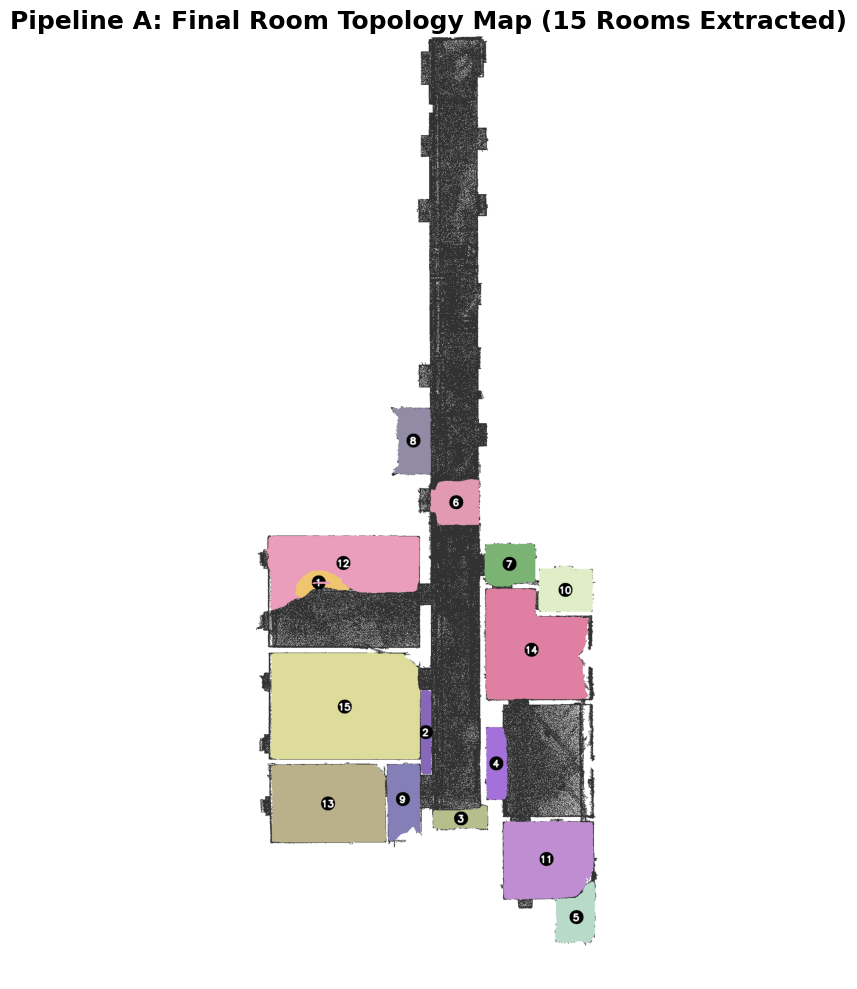

Map successfully saved to /content/Pipeline_A_Numbered_Rooms.png


In [7]:
print("--- 🗺️ VISUALIZATION 2: FINAL ROOM TOPOLOGY MAP ---")

# 1. Create a blank white canvas
img_rooms = np.full((height, width, 3), 255, dtype=np.uint8)

# 2. Draw the base walls (Dark Grey) to give the map structure
wall_mask = (Ms_grid == 0)
img_rooms[wall_mask] = [50, 50, 50]

# 3. Helper function to find the physical center of an irregular mask
def get_mask_centroid(mask_2d):
    m = cv2.moments(mask_2d.astype(np.uint8))
    if m["m00"] != 0:
        cx = int(m["m10"] / m["m00"])
        cy = int(m["m01"] / m["m00"])
        return cx, cy
    return None, None

# 4. Paint each validated room and apply its numerical ID
# We loop through clean_masks (these are the ones that survived our 4 filters!)
for idx, mask_data in enumerate(clean_masks):
    room_num = idx + 1 # 1-based indexing for human readability
    mask_2d = mask_data['segmentation']

    # Generate a random vibrant color (Keeping values high so text stays readable)
    color = np.random.randint(100, 240, 3).tolist()

    # Paint the room mask onto the canvas
    img_rooms[mask_2d] = color

    # Find the center of the room to place the text
    cx, cy = get_mask_centroid(mask_2d)

    if cx is not None and cy is not None:
        # Draw a small black circle background for the number so it pops
        cv2.circle(img_rooms, (cx, cy), 16, (0, 0, 0), -1)

        # Center the text mathematically
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.7
        thickness = 2
        text_size = cv2.getTextSize(str(room_num), font, font_scale, thickness)[0]
        text_x = cx - text_size[0] // 2
        text_y = cy + text_size[1] // 2

        # Draw the white numerical ID
        cv2.putText(img_rooms, str(room_num), (text_x, text_y), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)

# 5. Render the high-resolution map
plt.figure(figsize=(14, 10))
plt.imshow(img_rooms) # Matplotlib expects RGB, and our random colors are RGB safe
plt.title(f"Pipeline A: Final Room Topology Map ({len(clean_masks)} Rooms Extracted)", fontsize=18, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# 6. Save a copy to the Colab files pane
# (We must flip RGB to BGR for OpenCV's imwrite)
output_path = '/content/Pipeline_A_Numbered_Rooms.png'
cv2.imwrite(output_path, cv2.cvtColor(img_rooms, cv2.COLOR_RGB2BGR))
print(f"Map successfully saved to {output_path}")

## 📦 Phase 3: Batch Export & Download
**What this does:** Downloading dozens of individual `.ply` files manually from Google Colab is tedious and prone to data loss. This script automates the final extraction of our pipeline:
1. **Scans the Workspace:** Locates all mathematically validated 3D room files generated by Pipeline A.
2. **Compresses:** Bundles them into a single, clean `.zip` archive to preserve file structures.
3. **Downloads:** Automatically triggers a browser download directly to your local machine.

*(Note: Before running, you can update the `zip_filename` variable in the code below to easily track different benchmark runs, datasets, or hyperparameter tests!)*

In [8]:
# 1. Define the archive name
zip_filename = '/content/June24_Test1.zip' #change name depending on what point cloud im testing & which attempt in case not good on first try

# 2. Find all the generated SAM room files
ply_files = [f for f in os.listdir('/content/') if f.startswith('SAM_room_') and f.endswith('.ply')]

if len(ply_files) == 0:
    print("WARNING: No room files found in /content/")
else:
    print(f"Found {len(ply_files)} segmented rooms. Compressing into a single archive...")

    # 3. Zip them together
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for file in ply_files:
            file_path = os.path.join('/content/', file)
            # arcname prevents the zip from creating a useless "/content/" folder inside itself
            zipf.write(file_path, arcname=file)

    print("Compression complete! Initiating download to your Mac...")

    # 4. Trigger the browser download
    files.download(zip_filename)

Found 15 segmented rooms. Compressing into a single archive...
Compression complete! Initiating download to your Mac...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>